In [3]:
import datetime as dt
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools


In [4]:

def extract_msg(line):
    "Regex to extract datetime, sender and message."
    date = []
    time = []
    msg = []
    sender_name = []
    datetime_pat  = "(\d+/\d+/\d+) (\d+:\d+) - (.*?): (.*)"  
    msgdata = re.findall(datetime_pat, line)
    date,time,sender_name, msg = msgdata[0][0],msgdata[0][1],msgdata[0][2],msgdata[0][3]
#     sender_pat = "\-\ [^:]*" #"\-\ \w+\:|\-\ \w+\ \w+\:" # one or two names
#     sender = re.findall(sender_pat,line)

#     if date and sender:
#         if len(sender.group(0)) < 25:
#             # assumes a name and last name is less than at most N chars. 
#             # Avoids misclassifying a status change with a semi-colon for a name.
#             date = pd.to_datetime(date.group(0))        
#             sender_name = sender.group(0)[2:]

#             msg = line[line.index(sender_name)+len(sender_name)+2:]
        
    return date, time, sender_name, msg

# parse the entire convo as a pd.dataframe

# f = open('chat/chat.txt', 'r', encoding='utf-8')
# conv0 = pd.DataFrame(columns=['date','sender','message'])
# for count, line in enumerate(f):
#     date, sender, msg  = extract_msg(line)
#     if sender and msg:
#         temp_df = pd.Series({'date':date ,'sender':sender,'message':msg})
#         conv0 = conv0.append(temp_df, ignore_index=True)
        
#f.close()

In [5]:
f = open('chat.txt', 'r', encoding='utf-8')
content = f.readlines()
content = [x.strip() for x in content] 
conv0 = pd.DataFrame(columns=['date',"time",'sender','message'])
erros = []
for i in range(len(content)):
    try :
        date,time,sender, msg  = extract_msg(content[i]);
        temp_df = pd.Series({'date':date ,"time": time,'sender':sender,'message':msg}) 
        conv0 = conv0.append(temp_df, ignore_index=True)
    except IndexError:
        #print(i)
        pass

f.close()

In [8]:
conv1copia = conv0
totaldedias = pd.date_range(start='2018-09-18', end='2020-02-7', periods=400).to_pydatetime().tolist()
diastot = []
for i in totaldedias:
    diastot.append(i.strftime("%d/%-m/%y")) #Lista dos totais

semduplicado = conv1copia.drop_duplicates("date")#Tirando duplicados
fechas = semduplicado["date"].tolist() #Lista dos usados

for dia in diastot: #Colocando todas as fechas no array
    if dia not in fechas:
        fechas.append(dia)
pd.to_datetime(conv0['time'], format='%H:%M')[0]

Timestamp('1900-01-01 21:04:00')

In [9]:
msgcadaum = pd.DataFrame(columns=['date','sb','ro', "alArg", "alV" , "an", "jf"]) #msgs roberto e da milena
       
convpordate = conv0.groupby("date")

for i in fechas:
    try:
        sb = len(convpordate.get_group(i).groupby("sender").get_group("Sebastian").index) #Separa msg por dia(i) depois por autor e agarra especificos
        ro = len(convpordate.get_group(i).groupby("sender").get_group("Roberto").index)
        alArg = len(convpordate.get_group(i).groupby("sender").get_group("AlvaroArg").index) #Separa msg por dia(i) depois por autor e agarra especificos
        alV = len(convpordate.get_group(i).groupby("sender").get_group("Alvaro(Valencia)").index) #Separa msg por dia(i) depois por autor e agarra especificos
        an = len(convpordate.get_group(i).groupby("sender").get_group("Andrés Colombia").index) #Separa msg por dia(i) depois por autor e agarra especificos
        jf = len(convpordate.get_group(i).groupby("sender").get_group("Jonfer").index) #Separa msg por dia(i) depois por autor e agarra especificos

        
        #tiempito = convpordate.get_group(i).groupby("sender").get_group("Roberto").index
        temp_df = pd.Series({'date':i , "sb" : sb, "ro" : ro, "alArg" : alArg  ,"alV" :alV, "an" :an, "jf" :jf}) 
        msgcadaum = msgcadaum.append(temp_df, ignore_index=True)
    except KeyError as e:
        sb = 0
        ro = 0
        alV = 0
        alArg = 0
        an = 0
        jf = 0
    temp_df = pd.Series({'date':i , "sb" : sb, "ro" : ro, "alArg" : alArg  ,"alV" :alV, "an" :an, "jf" :jf }) 
    msgcadaum = msgcadaum.append(temp_df, ignore_index=True)
    


#plt.plot(temp_df["date"], msgmi)
#msgcadaum["date"]

In [10]:
msgcadaum = pd.DataFrame(columns=['date','sb','ro', "alArg", "alV" , "an", "jf"]) #msgs roberto e da milena
       
convpordate = conv0.groupby("date")

for i in fechas:
    try:
        sb = len(convpordate.get_group(i).groupby("sender").get_group("Sebastian").index) #Separa msg por dia(i) depois por autor e agarra especificos
    except KeyError as e:
        sb = 0
    try:
        ro = len(convpordate.get_group(i).groupby("sender").get_group("Roberto").index)
    except KeyError as e:
        ro = 0    
    try:   
        alArg = len(convpordate.get_group(i).groupby("sender").get_group("AlvaroArg").index) #Separa msg por dia(i) depois por autor e agarra especificos
    except KeyError as e:
        alArg = 0  
    try:
        alV = len(convpordate.get_group(i).groupby("sender").get_group("Alvaro(Valencia)").index) #Separa msg por dia(i) depois por autor e agarra especificos
    except KeyError as e:
        alV = 0
    try:    
        an = len(convpordate.get_group(i).groupby("sender").get_group("Andrés Colombia").index) #Separa msg por dia(i) depois por autor e agarra especificos
    except KeyError as e:
        an = 0
    try:    
        jf = len(convpordate.get_group(i).groupby("sender").get_group("Jonfer").index) #Separa msg por dia(i) depois por autor e agarra especificos
    except KeyError as e:
        jf = 0
        
    #tiempito = convpordate.get_group(i).groupby("sender").get_group("Roberto").index
    temp_df = pd.Series({'date':i , "sb" : sb, "ro" : ro, "alArg" : alArg  ,"alV" :alV, "an" :an, "jf" :jf}) 
    msgcadaum = msgcadaum.append(temp_df, ignore_index=True)
    
    


#plt.plot(temp_df["date"], msgmi)
#msgcadaum["date"]

In [11]:

msgcadaum['date'] =pd.to_datetime(msgcadaum.date, format='%d/%m/%y')
msgcadaum = msgcadaum.sort_values(by='date')
msgcadaum["date"] = msgcadaum["date"].apply(lambda x: x.strftime('%d/%m/%y')) 


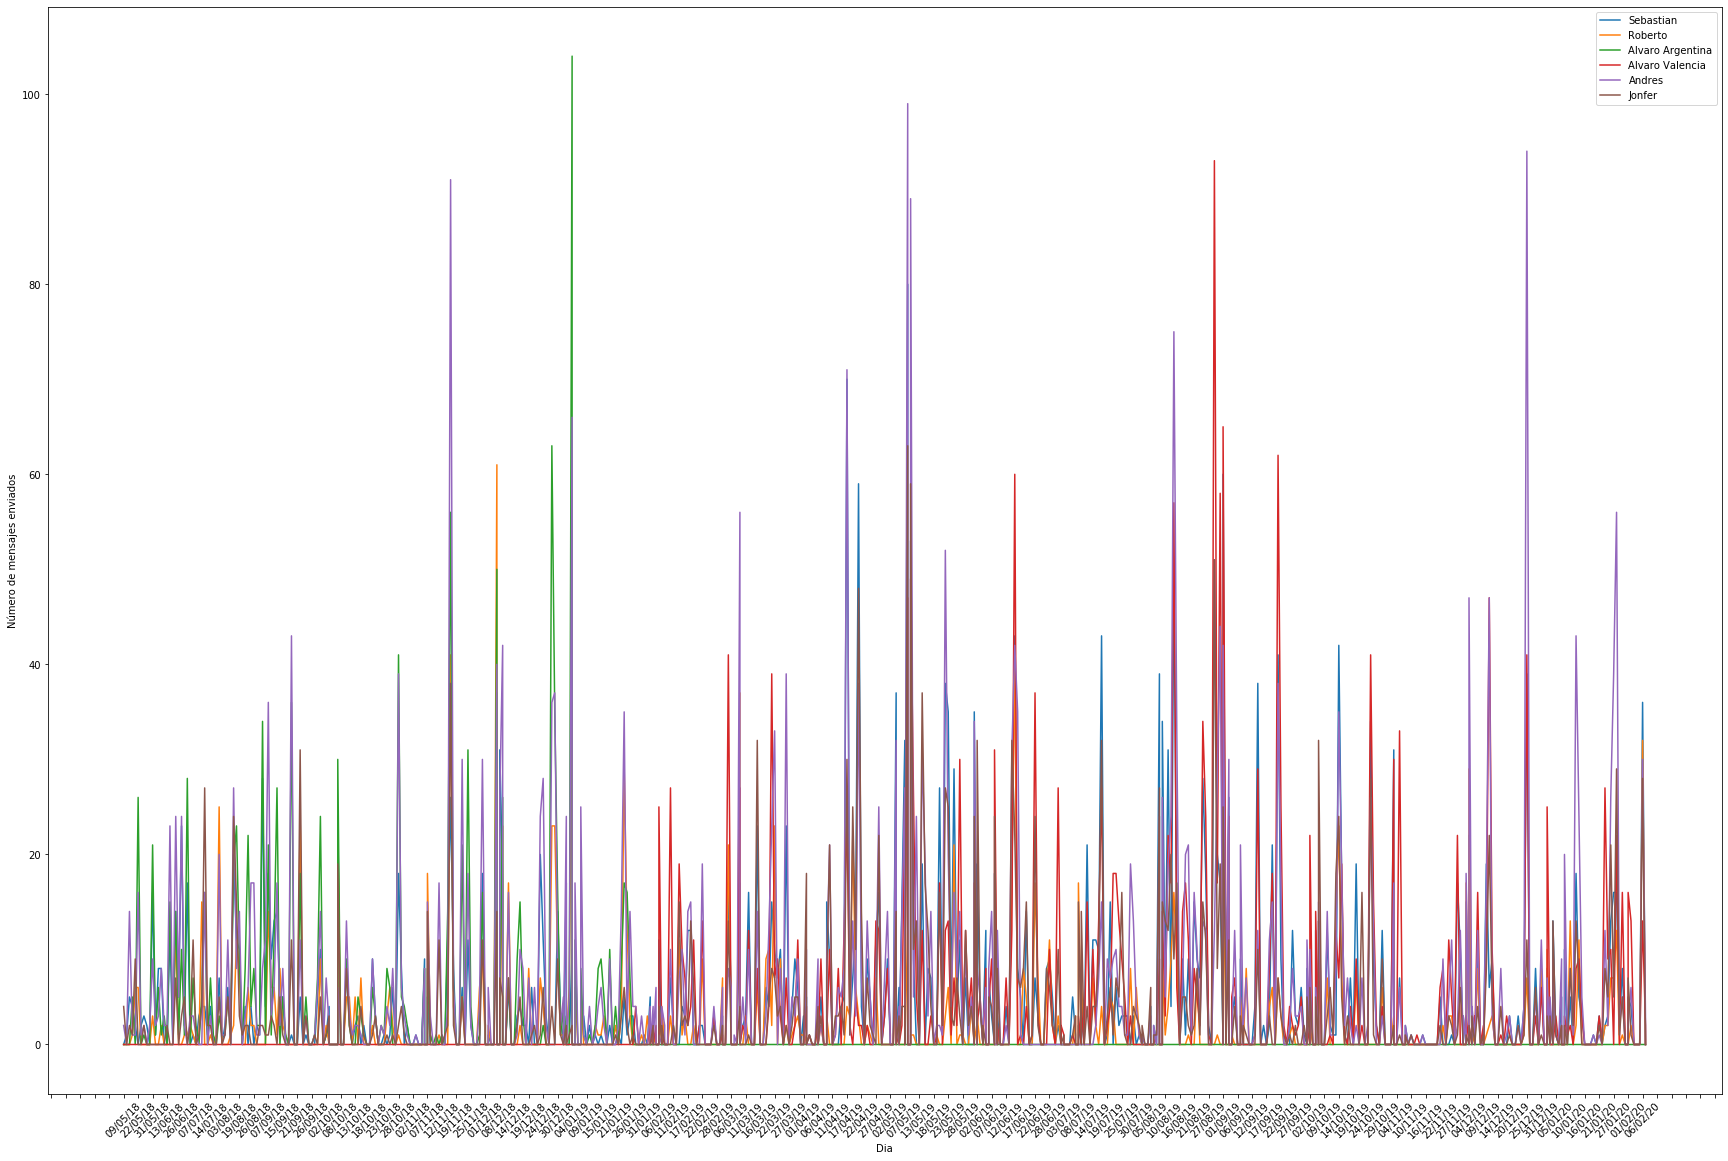

In [12]:

fig, ax1 = plt.subplots(figsize=(30,20))
ax1.set_ylabel(r"Número de mensajes enviados")
ax1.set_xlabel(r"Dia")
ax1.xaxis.set_major_locator(plt.MaxNLocator(130))
plt.xticks(rotation=45)



plt.plot(msgcadaum["date"], msgcadaum["sb"], label = "Sebastian")
plt.plot(msgcadaum["date"], msgcadaum["ro"], label = "Roberto")
plt.plot(msgcadaum["date"], msgcadaum["alArg"], label = "Alvaro Argentina")
plt.plot(msgcadaum["date"], msgcadaum["alV"], label = "Alvaro Valencia")
plt.plot(msgcadaum["date"], msgcadaum["an"], label = "Andres")
plt.plot(msgcadaum["date"], msgcadaum["jf"], label = "Jonfer")




ax1.legend(loc='best')
fig.savefig("amiguinhos.pdf", bbox_inches='tight')

In [13]:
totalsb = msgcadaum["sb"].sum()
totalro = msgcadaum["ro"].sum()
totalalAr = msgcadaum["alArg"].sum()
totalalV = msgcadaum["alV"].sum()
totalan = msgcadaum["an"].sum()
totaljf = msgcadaum["jf"].sum()
totalAl = totalalAr + totalalV

performance = [totalsb, totalro, totalAl, totalan, totaljf]
print(performance)


[3244, 1484, 3641, 4257, 2278]


[3244, 1484, 3641, 4257, 2278]


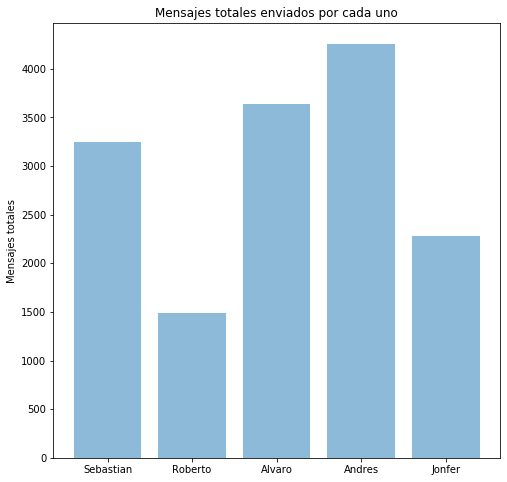

In [14]:
fig, ax1 = plt.subplots(figsize=(8,8))

objects = ("Sebastian", "Roberto", "Alvaro", "Andres", "Jonfer")
y_pos = np.arange(len(objects))
performance = [totalsb, totalro, totalAl, totalan, totaljf]
print(performance)
plt.bar(y_pos, performance, align='center', alpha=0.5)
plt.xticks(y_pos, objects)
plt.ylabel('Mensajes totales')
plt.title("Mensajes totales enviados por cada uno")

plt.show()
fig.savefig("amiguinhostotales.pdf", bbox_inches='tight')